In [1]:
import pandas as pd

# Ladda filerna för inspektion
data_path = r'data/breast-cancer.data'
names_path = r'data/breast-cancer.names'

# Försök att läsa in datafilen och undersöka dess struktur
columns = [
    "Class",  # Target variabel
    "age",
    "menopause",
    "tumor-size",
    "inv-nodes",
    "node-caps",
    "deg-malig",
    "breast",
    "breast-quad",
    "irradiat",
]
data = pd.read_csv(data_path, header=None, names=columns)

# Visa en översikt av data
data_overview = data.head(), data.info(), data.describe(include='all')
data_overview

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Class        286 non-null    object
 1   age          286 non-null    object
 2   menopause    286 non-null    object
 3   tumor-size   286 non-null    object
 4   inv-nodes    286 non-null    object
 5   node-caps    286 non-null    object
 6   deg-malig    286 non-null    int64 
 7   breast       286 non-null    object
 8   breast-quad  286 non-null    object
 9   irradiat     286 non-null    object
dtypes: int64(1), object(9)
memory usage: 22.5+ KB


(                  Class    age menopause tumor-size inv-nodes node-caps  \
 0  no-recurrence-events  30-39   premeno      30-34       0-2        no   
 1  no-recurrence-events  40-49   premeno      20-24       0-2        no   
 2  no-recurrence-events  40-49   premeno      20-24       0-2        no   
 3  no-recurrence-events  60-69      ge40      15-19       0-2        no   
 4  no-recurrence-events  40-49   premeno        0-4       0-2        no   
 
    deg-malig breast breast-quad irradiat  
 0          3   left    left_low       no  
 1          2  right    right_up       no  
 2          2   left    left_low       no  
 3          2  right     left_up       no  
 4          2  right   right_low       no  ,
 None,
                        Class    age menopause tumor-size inv-nodes node-caps  \
 count                    286    286       286        286       286       286   
 unique                     2      6         3         11         7         3   
 top     no-recurrence-even

C:\Users\User-9100\AppData\Local\Temp\ipykernel_3780\3925616555.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\User-9100\AppData\Local\Temp\ipykernel_3780\3925616555.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])


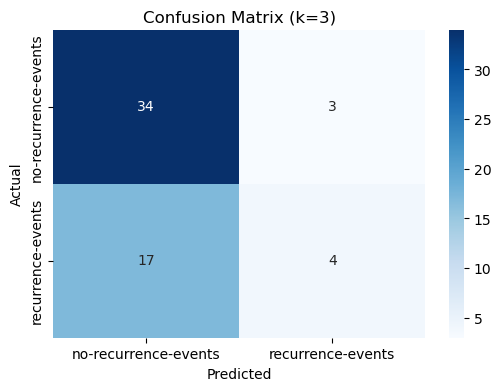

Accuracy for k=3: 0.66


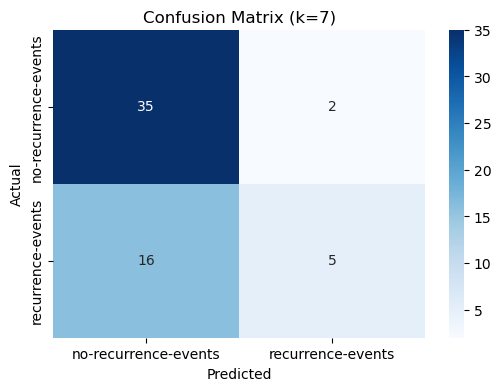

Accuracy for k=7: 0.69


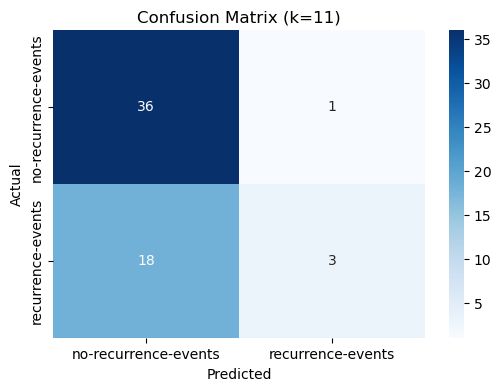

Accuracy for k=11: 0.67


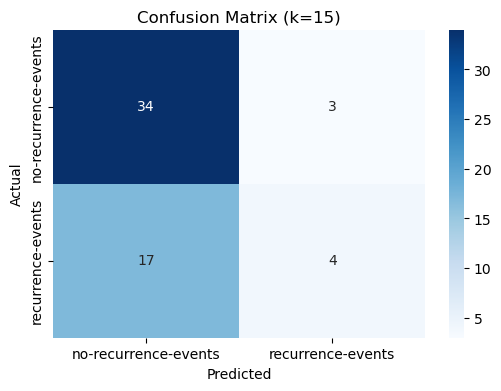

Accuracy for k=15: 0.66


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Välj attribut och målvariabel
selected_columns = ["tumor-size", "deg-malig", "inv-nodes"]
X = data[selected_columns]
y = data["Class"]

# Omvandla kategoriska variabler till numeriska
label_encoders = {}
for col in X.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Omvandla målvariabeln till numerisk
y_encoder = LabelEncoder()
y = y_encoder.fit_transform(y)

# Dela data i träning och test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Funktion för att köra kNN och visa resultat
def run_knn(k):
    # Träna kNN-modellen
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Gör förutsägelser
    y_pred = knn.predict(X_test)

    # Beräkna och visa confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=y_encoder.classes_, yticklabels=y_encoder.classes_)
    plt.title(f"Confusion Matrix (k={k})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    print(f"Accuracy for k={k}: {acc:.2f}")

# Kör kNN för olika värden på k
for k in [3, 7, 11, 15]:
    run_knn(k)

Resultat med icke-normaliserat data:


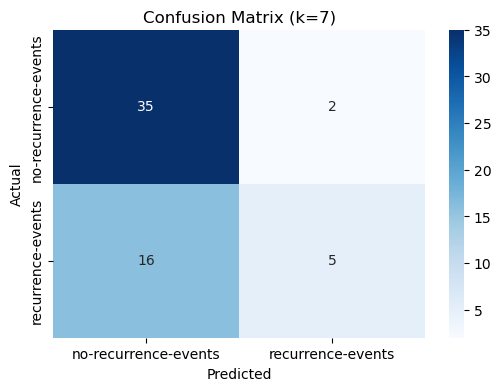

Accuracy for k=7: 0.69
Resultat med normaliserat data:


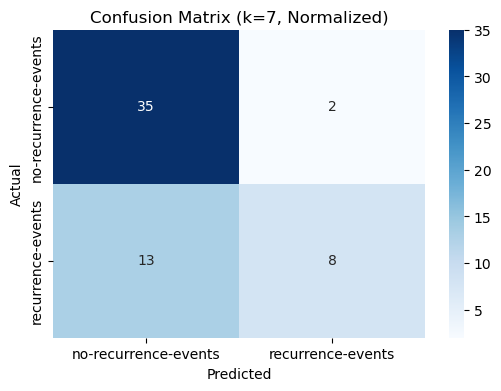

Accuracy for k=7 (Normalized): 0.74


In [5]:
from sklearn.preprocessing import MinMaxScaler

# Funktion för att normalisera data
def normalize_data(X):
    scaler = MinMaxScaler()
    X_normalized = scaler.fit_transform(X)
    return pd.DataFrame(X_normalized, columns=X.columns)

# Kör kNN för icke-normaliserat data
print("Resultat med icke-normaliserat data:")
run_knn(k=7)

# Normalisera data
X_normalized = normalize_data(X)

# Dela upp det normaliserade datat i träning och test
X_train_norm, X_test_norm, y_train_norm, y_test_norm = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42
)

# Anpassa funktionen för att köra kNN med normaliserat data
def run_knn_normalized(k, X_train, X_test, y_train, y_test):
    # Träna kNN-modellen
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Gör förutsägelser
    y_pred = knn.predict(X_test)

    # Beräkna och visa confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=y_encoder.classes_, yticklabels=y_encoder.classes_)
    plt.title(f"Confusion Matrix (k={k}, Normalized)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    print(f"Accuracy for k={k} (Normalized): {acc:.2f}")

# Kör kNN för normaliserat data
print("Resultat med normaliserat data:")
run_knn_normalized(k=7, X_train=X_train_norm, X_test=X_test_norm, y_train=y_train_norm, y_test=y_test_norm)

Resultat #1:
  k: 5
  Train/Test Split: 66/33
  Dataset Type: Normalized
  Accuracy: 0.75
  Confusion Matrix:
[[64  4]
 [20  8]]



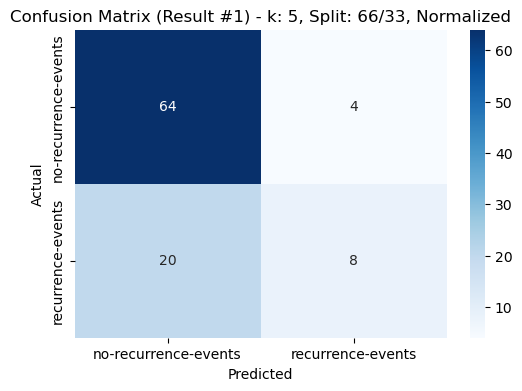

Resultat #2:
  k: 7
  Train/Test Split: 66/33
  Dataset Type: Normalized
  Accuracy: 0.75
  Confusion Matrix:
[[66  2]
 [22  6]]



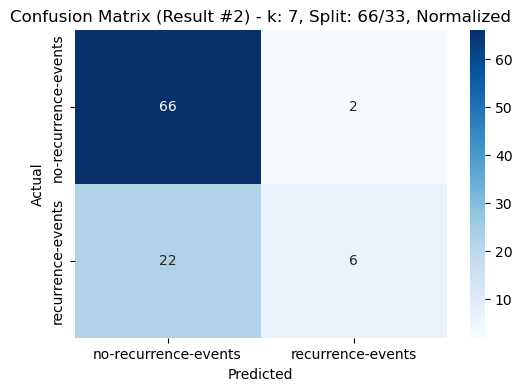

Resultat #3:
  k: 3
  Train/Test Split: 66/33
  Dataset Type: Normalized
  Accuracy: 0.74
  Confusion Matrix:
[[61  7]
 [18 10]]



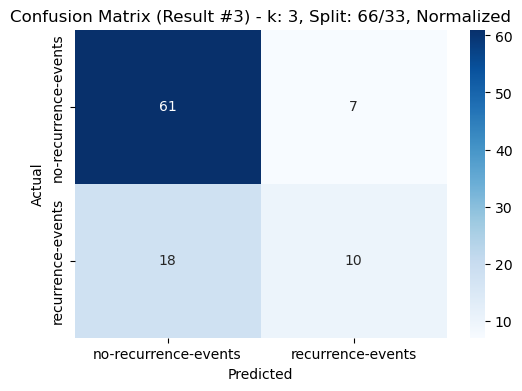

In [7]:
# Funktion för att köra kNN för alla kombinationer och samla resultat
def run_all_combinations(X, y):
    results = []
    k_values = [3, 5, 7]  # Tre olika värden på k
    train_test_splits = [(0.75, 0.25), (2 / 3, 1 / 3), (0.5, 0.5)]  # Tre olika splits
    dataset_types = ["Original", "Normalized"]  # Två datasetformat

    for k in k_values:
        for train_size, test_size in train_test_splits:
            for dataset_type in dataset_types:
                # Normalisera data om det behövs
                if dataset_type == "Normalized":
                    X_current = normalize_data(X)
                else:
                    X_current = X

                # Dela data i träning och test
                X_train, X_test, y_train, y_test = train_test_split(
                    X_current, y, train_size=train_size, test_size=test_size, random_state=42
                )

                # Träna och testa kNN
                knn = KNeighborsClassifier(n_neighbors=k)
                knn.fit(X_train, y_train)
                y_pred = knn.predict(X_test)

                # Beräkna confusion matrix och accuracy
                cm = confusion_matrix(y_test, y_pred)
                acc = accuracy_score(y_test, y_pred)

                # Spara resultat
                results.append({
                    "k": k,
                    "Train/Test Split": f"{int(train_size * 100)}/{int(test_size * 100)}",
                    "Dataset Type": dataset_type,
                    "Accuracy": acc,
                    "Confusion Matrix": cm
                })

    return results

# Kör alla kombinationer och samla resultaten
all_results = run_all_combinations(X, y)

# Sortera resultaten efter högst accuracy
sorted_results = sorted(all_results, key=lambda x: x["Accuracy"], reverse=True)

# Visa de tre bästa resultaten
top_3_results = sorted_results[:3]

# Funktion för att visa resultaten i text och plotta Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

def display_results(result, rank):
    cm = result["Confusion Matrix"]
    acc = result["Accuracy"]
    k = result["k"]
    split = result["Train/Test Split"]
    dataset_type = result["Dataset Type"]

    print(f"Resultat #{rank}:")
    print(f"  k: {k}")
    print(f"  Train/Test Split: {split}")
    print(f"  Dataset Type: {dataset_type}")
    print(f"  Accuracy: {acc:.2f}")
    print(f"  Confusion Matrix:\n{cm}\n")
    
    # Plot Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=y_encoder.classes_, yticklabels=y_encoder.classes_)
    plt.title(f"Confusion Matrix (Result #{rank}) - k: {k}, Split: {split}, {dataset_type}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Visa de tre bästa resultaten
for rank, result in enumerate(top_3_results, start=1):
    display_results(result, rank)
